# Explore Dataset: Data Analysis and Vocabulary Visualization

This notebook:
- loads all papers from `Dataset/*.csv`
- harmonizes schema across files
- analyzes class distribution and text statistics
- visualizes vocabulary patterns per category with word clouds

In [7]:
import subprocess
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')


def ensure_wordcloud_installed():
    """Install wordcloud in the active kernel if missing."""
    try:
        from wordcloud import WordCloud  # noqa: F401
    except Exception:
        print('wordcloud package not found. Installing now...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud'])
        print('wordcloud installed successfully.')


ensure_wordcloud_installed()
from wordcloud import STOPWORDS, WordCloud

## Load and Harmonize All Dataset CSVs

`survey_papers_901.csv` uses `arxiv_title` and `arxiv_abstract`, and does not contain a `label` column. We assign `SURVEY` for that file.

In [8]:
dataset_dir = Path('Dataset')
csv_paths = sorted(dataset_dir.glob('*.csv'))
print('CSV files found:', [p.name for p in csv_paths])

frames = []

for path in csv_paths:
    temp = pd.read_csv(path)

    if {'label', 'title', 'abstract'}.issubset(temp.columns):
        use = temp[['label', 'title', 'abstract']].copy()
    elif {'arxiv_title', 'arxiv_abstract'}.issubset(temp.columns):
        use = temp[['arxiv_title', 'arxiv_abstract']].copy()
        use = use.rename(columns={'arxiv_title': 'title', 'arxiv_abstract': 'abstract'})
        use['label'] = 'SURVEY'
    else:
        print(f'Skipping {path.name}: expected text columns were not found.')
        continue

    use['source_file'] = path.name
    frames.append(use)

all_df = pd.concat(frames, ignore_index=True)

before = len(all_df)
all_df = all_df.dropna(subset=['label', 'title', 'abstract']).copy()
all_df['label'] = all_df['label'].astype(str).str.strip().str.upper()
all_df['title'] = all_df['title'].astype(str)
all_df['abstract'] = all_df['abstract'].astype(str)
after = len(all_df)

all_df['combined_text'] = (all_df['title'] + ' ' + all_df['abstract']).str.replace(r'\s+', ' ', regex=True).str.strip()
all_df = all_df[all_df['combined_text'].str.len() > 0].copy()

print('Rows before cleaning:', before)
print('Rows after cleaning :', after)
print('Final shape         :', all_df.shape)
all_df.head()

CSV files found: ['applied_papers_1000.csv', 'survey_papers_901.csv', 'theory_papers_1000.csv']
Rows before cleaning: 2901
Rows after cleaning : 2901
Final shape         : (2901, 5)


,label,title,abstract,source_file,combined_text
0,APPLIED,Towards Generalizable Robotic Manipulation in ...,Vision-Language-Action (VLA) models excel in s...,applied_papers_1000.csv,Towards Generalizable Robotic Manipulation in ...
1,APPLIED,Mixture-of-Depths Attention,Scaling depth is a key driver for large langua...,applied_papers_1000.csv,Mixture-of-Depths Attention Scaling depth is a...
2,APPLIED,Look Before Acting: Enhancing Vision Foundatio...,Vision-Language-Action (VLA) models have recen...,applied_papers_1000.csv,Look Before Acting: Enhancing Vision Foundatio...
3,APPLIED,HorizonMath: Measuring AI Progress Toward Math...,"Can AI make progress on important, unsolved ma...",applied_papers_1000.csv,HorizonMath: Measuring AI Progress Toward Math...
4,APPLIED,GlyphPrinter: Region-Grouped Direct Preference...,Generating accurate glyphs for visual text ren...,applied_papers_1000.csv,GlyphPrinter: Region-Grouped Direct Preference...


## Evaluate All Papers: Distribution and Text Statistics

,label,count,percentage
0,APPLIED,1000,34.47
1,THEORETICAL,1000,34.47
2,SURVEY,901,31.06


,label,papers,avg_chars,median_chars,avg_words,median_words
0,APPLIED,1000,1475.40,1478.0,191.49,190.0
1,SURVEY,901,1176.96,1176.0,169.17,169.0
2,THEORETICAL,1000,1268.85,1253.5,180.90,179.0


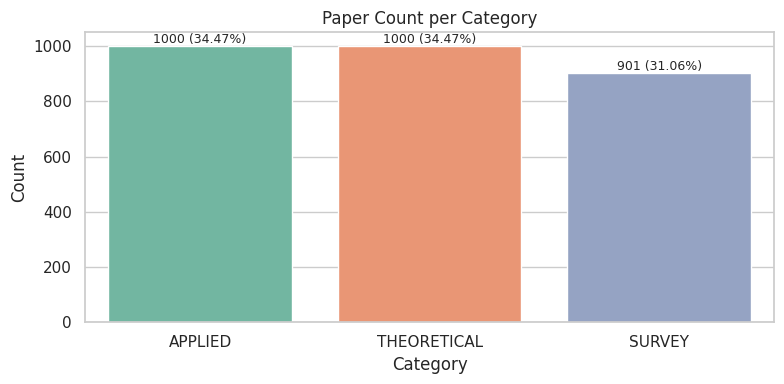

In [9]:
label_counts = all_df['label'].value_counts().sort_values(ascending=False)
label_pct = (label_counts / label_counts.sum() * 100).round(2)
dist_df = pd.DataFrame({
    'label': label_counts.index,
    'count': label_counts.values,
    'percentage': label_pct.values
})

display(dist_df)

all_df['text_char_len'] = all_df['combined_text'].str.len()
all_df['text_word_len'] = all_df['combined_text'].str.split().str.len()

len_stats = all_df.groupby('label', as_index=False).agg(
    papers=('label', 'size'),
    avg_chars=('text_char_len', 'mean'),
    median_chars=('text_char_len', 'median'),
    avg_words=('text_word_len', 'mean'),
    median_words=('text_word_len', 'median')
)

display(len_stats.round(2))

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=dist_df, x='label', y='count', hue='label', legend=False, palette='Set2')
for i, row in dist_df.reset_index(drop=True).iterrows():
    ax.text(i, row['count'], f"{int(row['count'])} ({row['percentage']}%)", ha='center', va='bottom', fontsize=9)
plt.title('Paper Count per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Text Preprocessing and Vocabulary Analysis

In [10]:
import re

def basic_tokenize(text):
    """Simple word tokenization: lowercase, split on whitespace and punctuation."""
    text = str(text).lower()
    tokens = re.findall(r'\b[a-z]+\b', text)
    return tokens

def get_top_words(texts, n=20):
    """Extract top n most frequent words from texts."""
    counter = Counter()
    for text in texts:
        counter.update(basic_tokenize(text))
    return counter.most_common(n)

# Analyze top words per category (raw, before stop word filtering)
print('Top 15 Raw Words per Category (before filtering)\n')
for label in sorted(all_df['label'].unique()):
    label_texts = all_df.loc[all_df['label'] == label, 'combined_text']
    top_words = get_top_words(label_texts, n=15)
    
    print(f'\n{label}:')
    print('-' * 50)
    for word, count in top_words:
        print(f'  {word:20s} : {count:5d}')

# Vocabulary richness per category
print('\n\n' + '=' * 60)
print('Vocabulary Richness Analysis')
print('=' * 60)

vocab_stats = []
for label in sorted(all_df['label'].unique()):
    label_texts = all_df.loc[all_df['label'] == label, 'combined_text']
    all_tokens = []
    for text in label_texts:
        all_tokens.extend(basic_tokenize(text))
    
    unique_tokens = len(set(all_tokens))
    total_tokens = len(all_tokens)
    vocabulary_ratio = unique_tokens / total_tokens if total_tokens > 0 else 0
    
    vocab_stats.append({
        'label': label,
        'unique_words': unique_tokens,
        'total_words': total_tokens,
        'vocabulary_ratio': vocabulary_ratio
    })

vocab_df = pd.DataFrame(vocab_stats)
display(vocab_df.round(4))

Top 15 Raw Words per Category (before filtering)


APPLIED:
--------------------------------------------------
  and                  :  6413
  the                  :  5769
  a                    :  4490
  to                   :  4387
  of                   :  3393
  in                   :  2762
  for                  :  2498
  we                   :  2232
  that                 :  2207
  on                   :  1833
  with                 :  1628
  this                 :  1300
  is                   :  1162
  by                   :  1076
  models               :  1051

SURVEY:
--------------------------------------------------
  the                  :  7155
  and                  :  5834
  of                   :  5788
  in                   :  3997
  to                   :  3617
  a                    :  3598
  we                   :  2346
  learning             :  2144
  for                  :  1919
  this                 :  1774
  on                   :  1623
  survey               

,label,unique_words,total_words,vocabulary_ratio
0,APPLIED,12134,201511,0.0602
1,SURVEY,7243,156117,0.0464
2,THEORETICAL,10323,188595,0.0547


## Word Cloud for Each Category

These clouds visualize frequent words per class using the full harmonized dataset text.

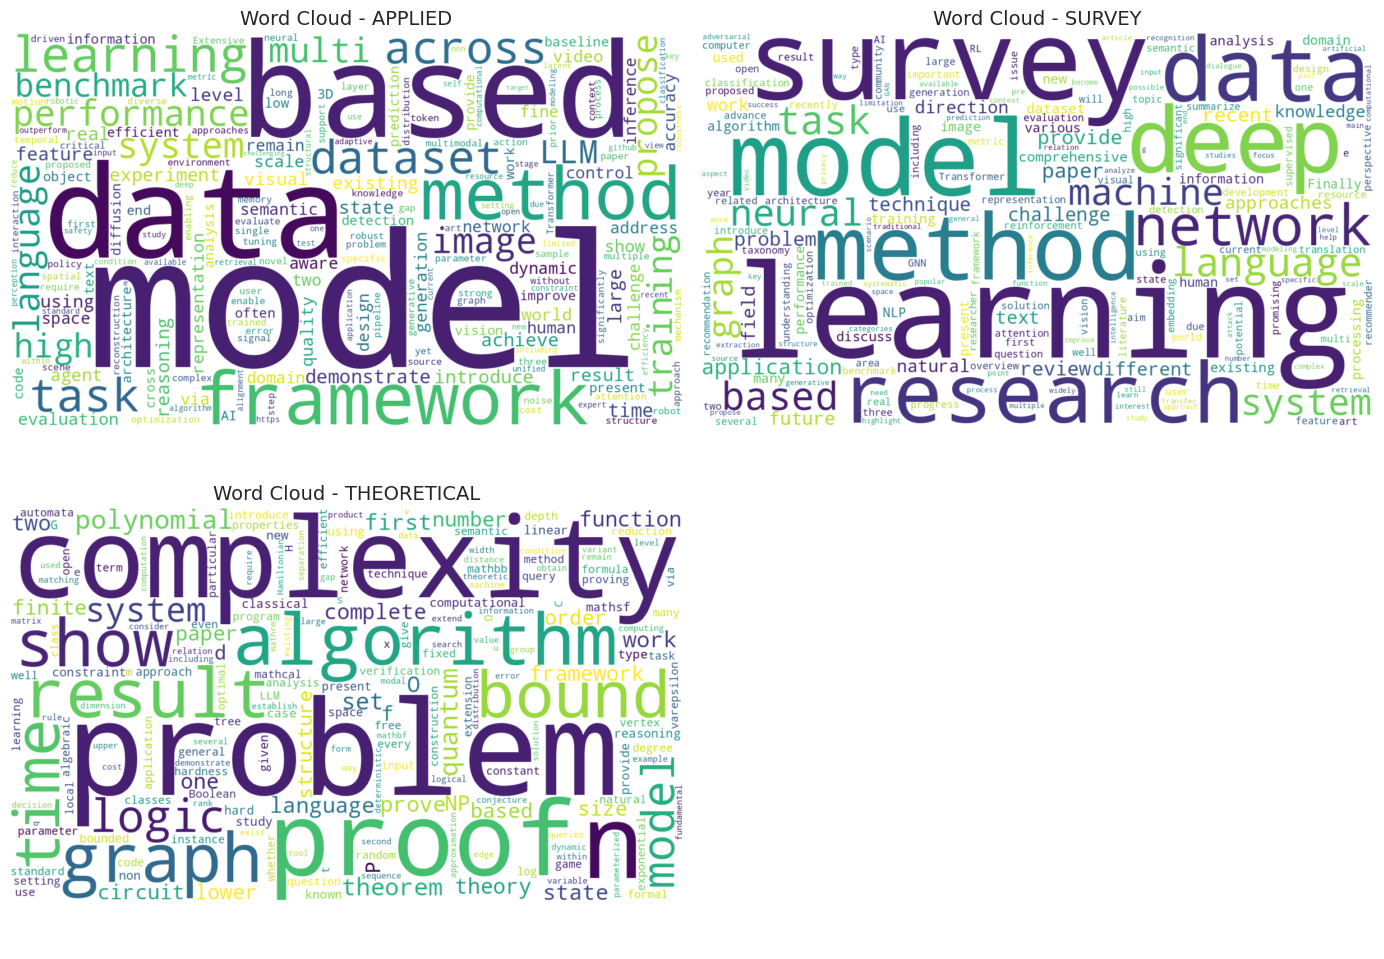

In [11]:
labels_sorted = sorted(all_df['label'].unique())
n_classes = len(labels_sorted)

ncols = 2
nrows = int(np.ceil(n_classes / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, label in enumerate(labels_sorted):
    text_blob = ' '.join(all_df.loc[all_df['label'] == label, 'combined_text'].tolist())

    wc = WordCloud(
        width=1200,
        height=700,
        background_color='white',
        stopwords=STOPWORDS,
        collocations=False,
        random_state=SEED
    ).generate(text_blob)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud - {label}', fontsize=14)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()